In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

# 1. Configure LaTeX rendering and font sizes for a single-column paper
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.figsize": (4., 3.5) # Standard single-column width in inches
})

def generate_publication_plot(csv_file, nq):
    # Load data
    df = pd.read_csv(csv_file)

    # Identify unique temperatures and sort them
    # Betas: Small value = High T, Large value = Low T
    betas = sorted(df['beta'].unique())
    # Define your specific color mapping
    # beta_min (High T) -> Red
    # beta_mid (Medium T) -> Yellow (using an orange-yellow for better visibility)
    # beta_max (Low T) -> Blue
    color_map = {
        betas[0]: '#e41a1c', # Red
        betas[1]: "#8dde00", # Yellow/Gold
        betas[2]: '#377eb8'  # Blue
    }

    fig, ax = plt.subplots()

    # Define a color palette for different temperatures (betas)
    betas = sorted(df['beta'].unique())
    palette = sns.color_palette("viridis", n_colors=len(betas))

    for i, beta in enumerate(betas):
        sub = df[df['beta'] == beta]
        ax.plot(sub['alpha'], sub['tvd'], 
                label=rf'$\beta = {beta}$', 
                color=color_map.get(beta, 'black'),
                marker='o', markersize=4, 
                linewidth=1.5, alpha=0.8)

    # Set log scales
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Labels and formatting
    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(r'TVD')
    # ax.set_title(f'Effect of Pauli Truncation ($n={nq}$)')
    
    # Legend and Grid
    ax.legend(frameon=False)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    # ax.grid(True, which="both", ls="--", lw=0.5, alpha=0.5)

    # # Remove top and right spines for a modern look
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

    # Tight layout to ensure it fits the single column nicely
    plt.tight_layout()
    
    # Save in high resolution for the paper
    output_name = f"tvd_analysis_heisenberg_nq{nq}.pdf"
    plt.savefig(output_name, bbox_inches='tight', dpi=300)
    print(f"Plot saved as {output_name}")
    plt.show()

Plot saved as tvd_analysis_heisenberg_nq6.pdf


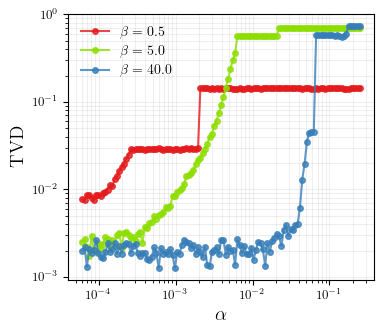

In [48]:
# Run the plotting function
generate_publication_plot("/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/paper_figures/figure_2/truncation_tvd_heisenberg_nq6.csv", 6)

Plot saved as tvd_analysis_heisenberg_nq6.pdf


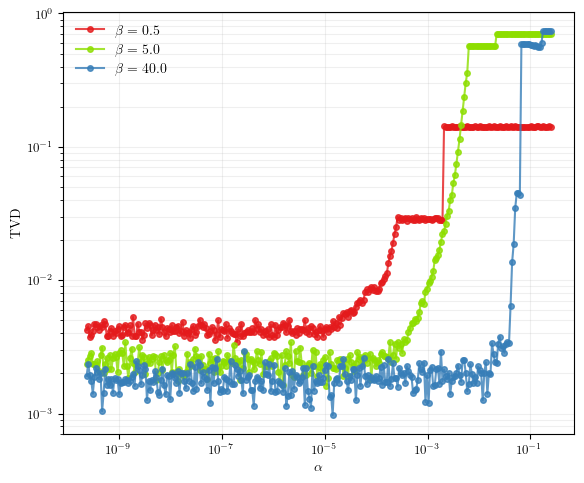

In [181]:
# Run the plotting function
generate_publication_plot("/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/paper_figures/figure_2/truncation_tvd_heisenberg_nq6_sampling.csv", 6)

Plot saved as tvd_analysis_heisenberg_nq6.pdf


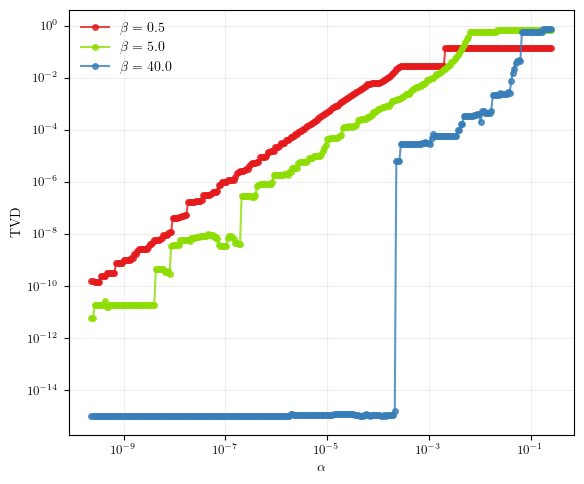

In [180]:
# Run the plotting function
generate_publication_plot("/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/paper_figures/figure_2/truncation_tvd_heisenberg_nq6_exact.csv", 6)

### for 12 qubits 

Plot saved as tvd_analysis_heisenberg_nq6.pdf


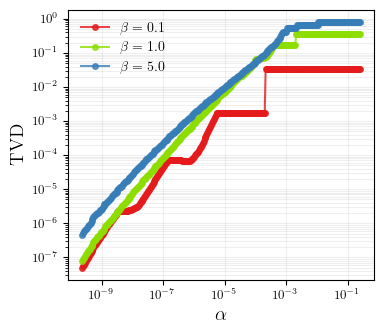

In [4]:
# Run the plotting function
generate_publication_plot("/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/paper_figures/figure_2/truncation_tvd_heisenberg_nq12_exact.csv", 6)

# for plot 2

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# LaTeX and Font Setup
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "figure.figsize": (6, 5)
})

def plot_3d_distribution_refined(csv_file, top_k=15):
    df = pd.read_csv(csv_file)
    
    # Filter for significant bitstrings to avoid clutter
    df = df.sort_values(by='exact', ascending=False).head(top_k).sort_values(by='bitstring')

    bitstrings = df['bitstring'].values
    # Columns are ['bitstring', 'exact', 'log2alpha_neg14', ...]
    alpha_cols = [c for c in df.columns if c != 'bitstring']
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Data dimensions
    num_x = len(bitstrings)
    num_y = len(alpha_cols)
    
    # Grid setup
    x_pos, y_pos = np.meshgrid(np.arange(num_x), np.arange(num_y))
    x_flat = x_pos.flatten()
    y_flat = y_pos.flatten()
    z_flat = np.zeros_like(x_flat)

    # Bar thickness and centering
    dx = 0.5 
    dy = 0.5
    dz = df[alpha_cols].values.T.flatten()

    # Color Mapping: Green (Exact) to Red (Highest Truncation)
    # plt.cm.RdYlGn_r goes Green -> Yellow -> Red
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, num_y))
    bar_colors = np.repeat(colors, num_x, axis=0)

    # Plotting (offsetting x and y by half thickness to center bars on ticks)
    ax.bar3d(x_flat - dx/2, y_flat - dy/2, z_flat, dx, dy, dz, 
             color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.1)

    # --- Fixing Labels and Ticks ---
    
    # X-axis: Bitstrings
    ax.set_xticks(np.arange(num_x))
    labels = [bin(b)[2:].zfill(6) for b in bitstrings]
    ax.set_xticklabels(labels, rotation=45,va='center', ha='right', fontsize=8)
    ax.set_xlabel(r'Bitstrings $x$', labelpad=10)

    # Y-axis: Alphas
    ax.set_yticks(np.arange(num_y))
    # Correctly parse the column names back to LaTeX math
    y_labels = []
    for c in alpha_cols:
        if c == 'exact': y_labels.append('Exact')
        else:
            exp = c.split('neg')[-1]
            y_labels.append(rf'$\alpha = 2^{{-{exp}}}$')
    ax.set_yticklabels(y_labels, fontsize=10, va='center')
    ax.set_ylabel(r'Coefficient Truncation', labelpad=6)

    # Clamping the limits ensures ticks are centered under the bars
    ax.set_ylim(-0.5, num_y - 0.5)
    
    # Z-axis: Probability
    ax.set_zlabel('') 
    ax.text2D(0.95, 0.78, r"$p(x)$", transform=ax.transAxes, fontsize=12)
    
    # Adjust viewing angle for better visibility
    ax.view_init(elev=25, azim=-50)

    # Tight layout and extra padding for the cut-off Z label
    plt.tight_layout()
    fig.subplots_adjust(left=0, right=1, bottom=0.1, top=1)
    
    plt.savefig("3d_hist_refined.pdf", bbox_inches='tight')
    plt.show()

/var/folders/p4/5739skqd2071x3f05l7p2mcm0000gn/T/ipykernel_79974/753157911.py:81: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


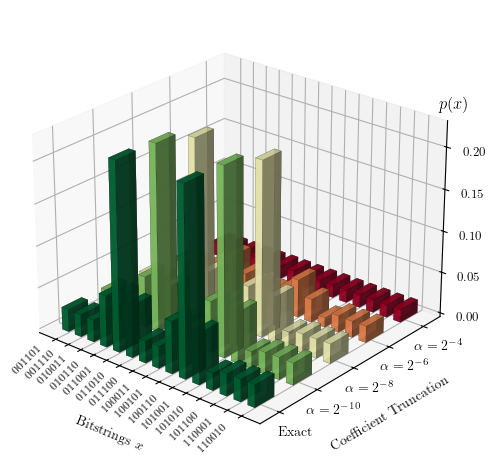

In [173]:
plot_3d_distribution_refined("/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/paper_figures/figure_2/hist3d_data_beta5.0.csv", top_k=15)